In [1]:
%cd ..
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path
import platform
import time
import warnings
from src.config import get_config
warnings.filterwarnings("ignore")

from ultralytics import YOLO
import torch
#DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
config = get_config()

print(f"Device: {config['device']}")
import ultralytics
print(f"Versao do Yolo: {ultralytics.__version__}")

yolo_custom = None

def detectar_yolo_custom(image_path, model, labels=[0,1], limiar_confianca=0.4):
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    inicio = time.time()
    resultados = model(
        img_rgb,
        conf=limiar_confianca,
        classes=labels,
        verbose=False
    )
    inferencia_ms = (time.time() - inicio) * 1000  # em ms
    retangulos = resultados[0].boxes
    deteccoes = []
    if retangulos is not None:
        for retang in retangulos:
            x1, y1, x2, y2 = retang.xyxy[0].cpu().numpy().astype(int)
            conf = float(retang.conf[0])
            deteccoes.append({"retang": (x1, y1, x2, y2), "conf": conf, 'cls': int(retang.cls.cpu().item())})
    
    return {
        "img": img_rgb,
        "deteccoes": deteccoes,
        "inferencia_ms": inferencia_ms,
        "num_deteccoes": len(deteccoes)
    }


def visualizar_deteccoes_yolo(result, title="YOLOv8 customizado"):
    fig, ax = plt.subplots(1, 1, figsize=(9, 6))
    ax.imshow(result["img"])
    cores = plt.cm.Set1(np.linspace(0, 1, max(len(result["deteccoes"]), 1)))
    for i, det in enumerate(result["deteccoes"]):
        x1, y1, x2, y2 = det["retang"]
        conf = det["conf"]
        label_name = yolo_custom.names[det["cls"]]
        color = cores[i % len(cores)]
        # retangulo deteccao
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2.5, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        # rótulo com confiança
        ax.text(
            x1, y1 - 6, f"{label_name.title()} {conf:.2f}",
            color="white", fontsize=9, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", facecolor=color, alpha=0.8)
        )
    
    ax.set_title(
        f"{title}\n"
        f"{result['num_deteccoes']} deteccoes | "
        f"Inferência: {result['inferencia_ms']:.1f}ms",
        fontsize=10, pad=12
    )
    ax.axis("off")
    plt.tight_layout()
    plt.savefig("output/yolo_deteccoes.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Salvo em output/yolo_deteccoes.png")

/Users/guilherme/00 IA/D06-Trabalho-final
Device: mps
Versao do Yolo: 8.4.41


------------------------------------------------------------
Classes disponíveis:
   ID 0: Pistola
   ID 1: Fuzil
------------------------------------------------------------
   Total de classes: 2
Resultado:
   deteccoes: 1
   Tempo de inferência: 26.1ms
   [1] retang=(np.int64(69), np.int64(52), np.int64(285), np.int64(235)) | confiança=0.951


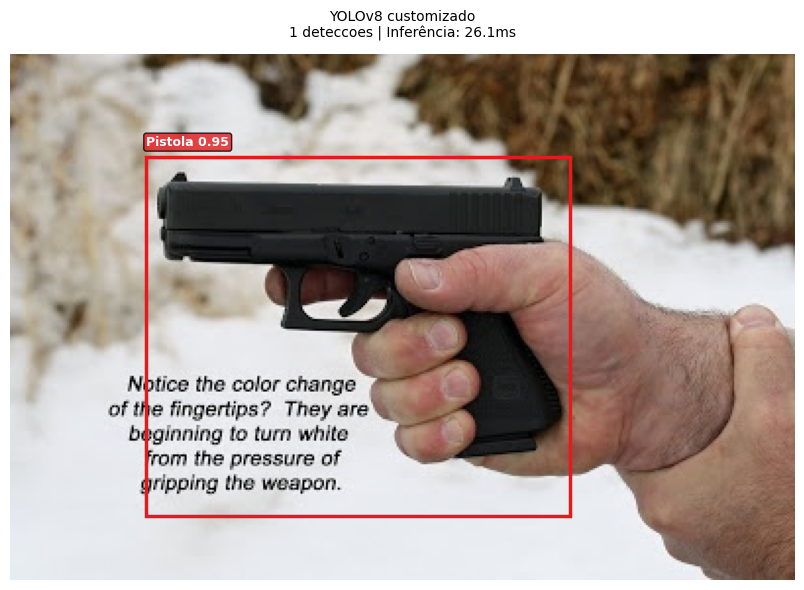

Salvo em output/yolo_deteccoes.png


In [ ]:
# path do melhor modelo do treino
yolo_custom = YOLO(config['my_model_path'])

print(60*'-')
print(f"Classes disponíveis:")
for id, name in yolo_custom.names.items():
    print(f"   ID {id}: {name}")

print(60*'-')
print(f"   Total de classes: {len(yolo_custom.names)}")

# Variar a imagem de teste para verificar as detecções
img_teste = "data/images/t6.jpg"
result = detectar_yolo_custom(img_teste, yolo_custom, labels=[0,1], limiar_confianca=0.2)
print(f"Resultado:")
print(f"   deteccoes: {result['num_deteccoes']}")
print(f"   Tempo de inferência: {result['inferencia_ms']:.1f}ms")
for i, d in enumerate(result["deteccoes"]):
    print(f"   [{i+1}] retang={d['retang']} | confiança={d['conf']:.3f}")
visualizar_deteccoes_yolo(result)

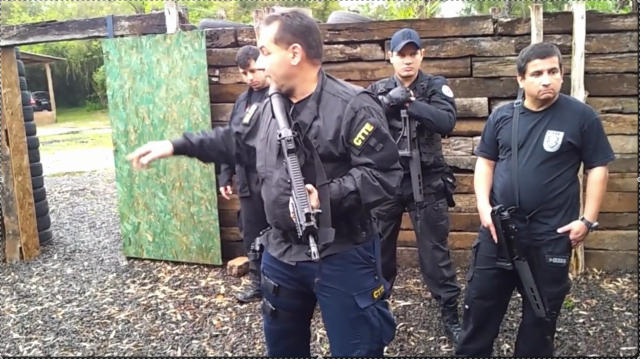

Câmera encerrada.


In [5]:
# 3a celula - viseo

#  Câmera local (descomente para usar localmente) 
from IPython.display import display, clear_output
cap = cv2.VideoCapture('data/video/video_teste.mov')
print("Pressione 'q' para encerrar | 'r' para registrar identidade")
using_cv = False
frame_idx = 0
captura_por_frames = 15
while True:
    ret, frame = cap.read()
    if not ret: break
    altura, largura = frame.shape[0:2]
    nova_largura = nova_altura = 640
    if largura > altura: nova_altura = int(nova_largura * (altura / largura))
    elif altura > largura: nova_largura = int(nova_altura * (largura / altura))
    frame = cv2.resize(frame, (nova_largura, nova_altura), interpolation=cv2.INTER_AREA)
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # YOLOv8
    if frame_idx%captura_por_frames == 0:
        yolo_res = yolo_custom(frame_rgb, conf=0.24, classes=[0, 1], verbose=False)
    
    if yolo_res[0].boxes is not None:
        for box in yolo_res[0].boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            cls = int(box.cls.cpu().item())
            conf = float(box.conf[0])
            label = f"{yolo_custom.names[cls]} ({conf:0.2f})"
            color = (80, 255, 140) if cls==0 else (80, 80, 255)
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(frame, label,
                        (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    if using_cv:
        try:
            cv2.imshow("YOLOv8 + InsightFace", frame)
            key = cv2.waitKey(1) & 0xFF
            if key == ord('q'): break
        except Exception as e:
            using_cv = False
            
    if not using_cv:
        # 3. Transforma o array em imagem PIL
        img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        print(img.size)
        # time.sleep(0.05)
        clear_output(wait=True)
        display(img)    
        
    frame_idx += 1
    if frame_idx >600: break

cap.release()

if using_cv:
    try:
        cv2.destroyAllWindows()
        cv2.waitKey(1)
    except Exception as e:
        pass

print("Câmera encerrada.")